## Load and Explore Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ===== LOAD DATA =====
df = pd.read_csv(r'../data/Telco_Customer_Churn.csv')

print("=" * 80)
print("CUSTOMER CHURN PREDICTION - DATA EXPLORATION")
print("=" * 80)

# Basic Info
print("\n📊 Dataset Overview:")
print(f"Total Customers: {len(df):,}")
print(f"Features: {len(df.columns)}")
print(f"\nColumns: {df.columns.tolist()}")

# Target Distribution
print("\n🎯 Churn Distribution:")
churn_dist = df['Churn'].value_counts()
print(churn_dist)
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

# Missing Values
print("\n🔍 Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values!")

# Data Types
print("\n📝 Data Types:")
print(df.dtypes.value_counts())

# Sample Data
print("\n📋 Sample Data:")
print(df.head())

## Exploratory Data Analysis (EDA)

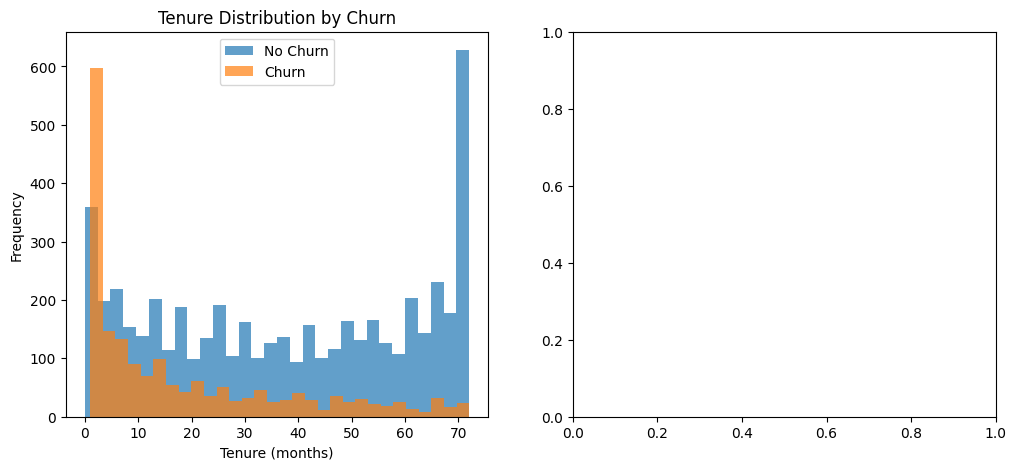

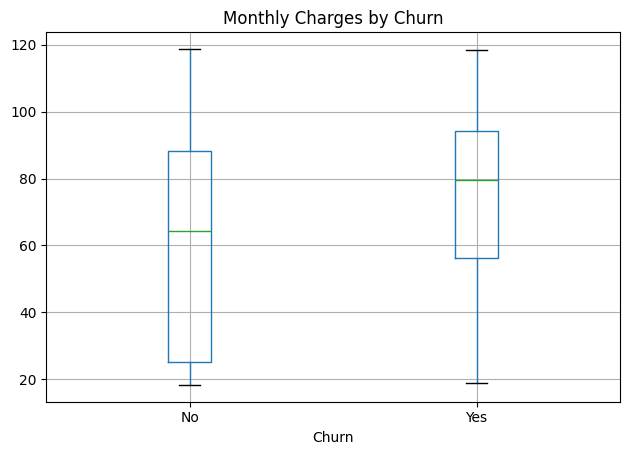


📊 Churn by Contract Type:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


<Figure size 1000x600 with 0 Axes>

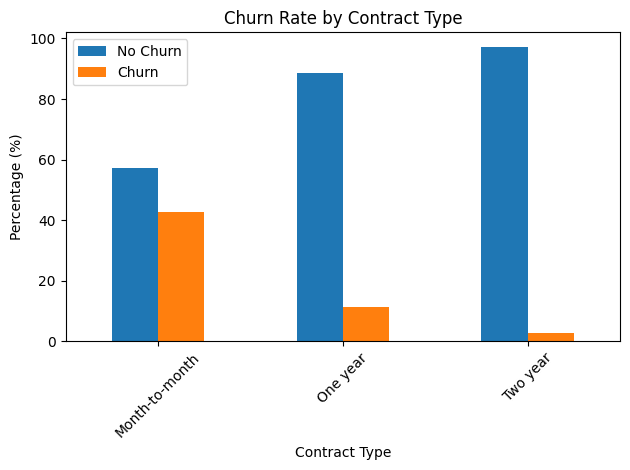


📊 Churn by Services:


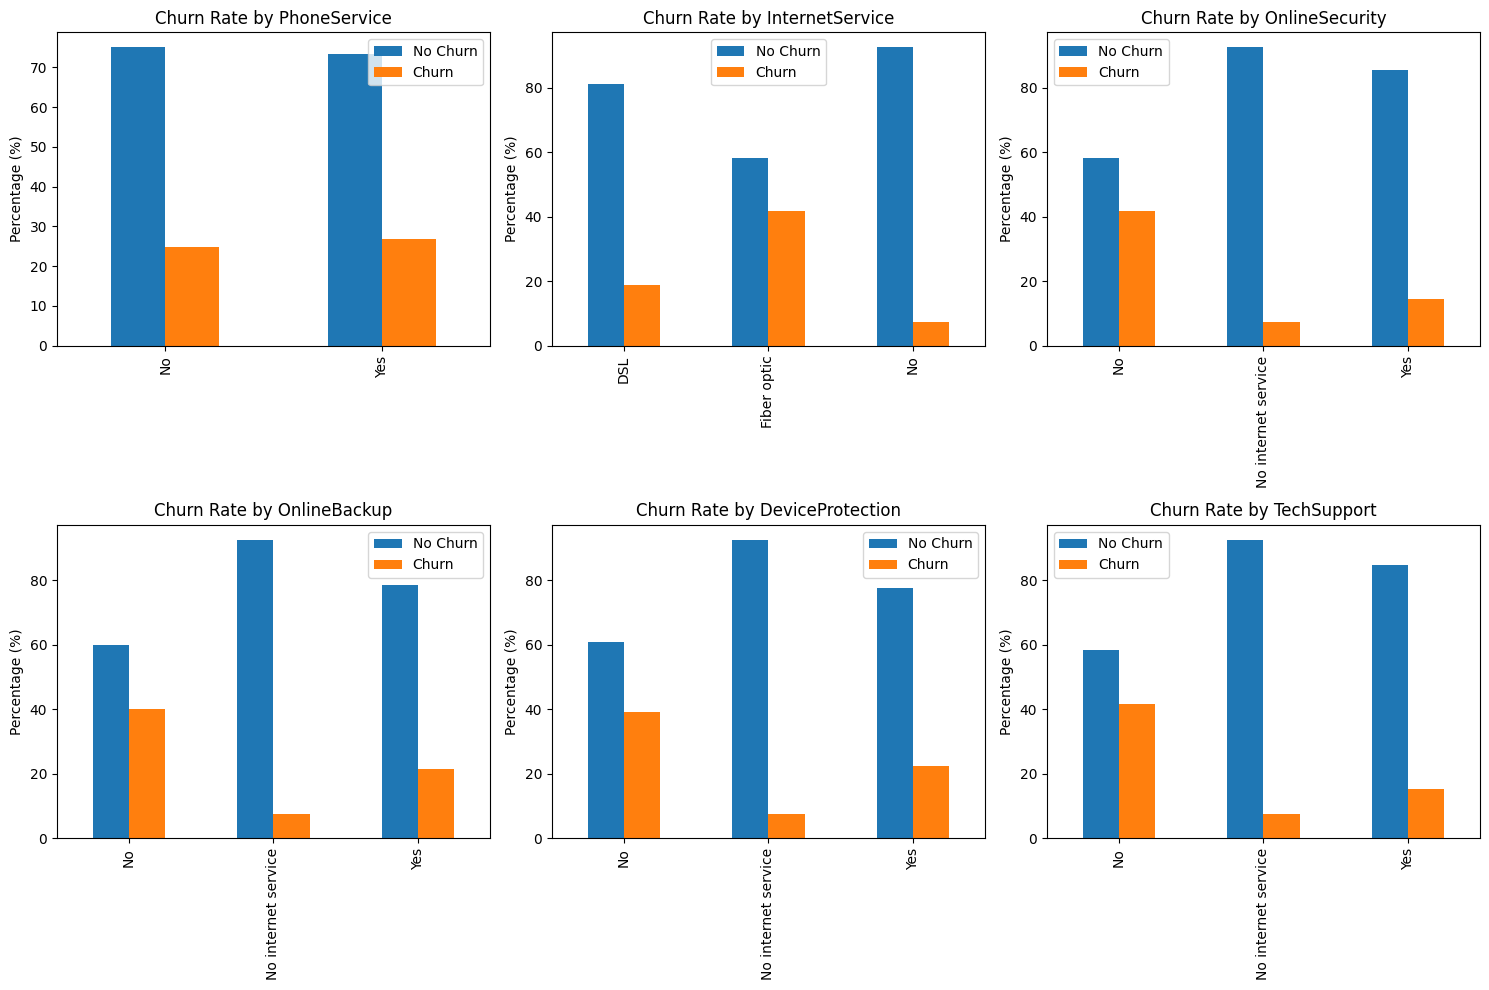


📊 Key Correlations with Churn:
Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
TotalCharges        0.014479
PhoneService        0.011942
gender             -0.008612
customerID         -0.017447
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


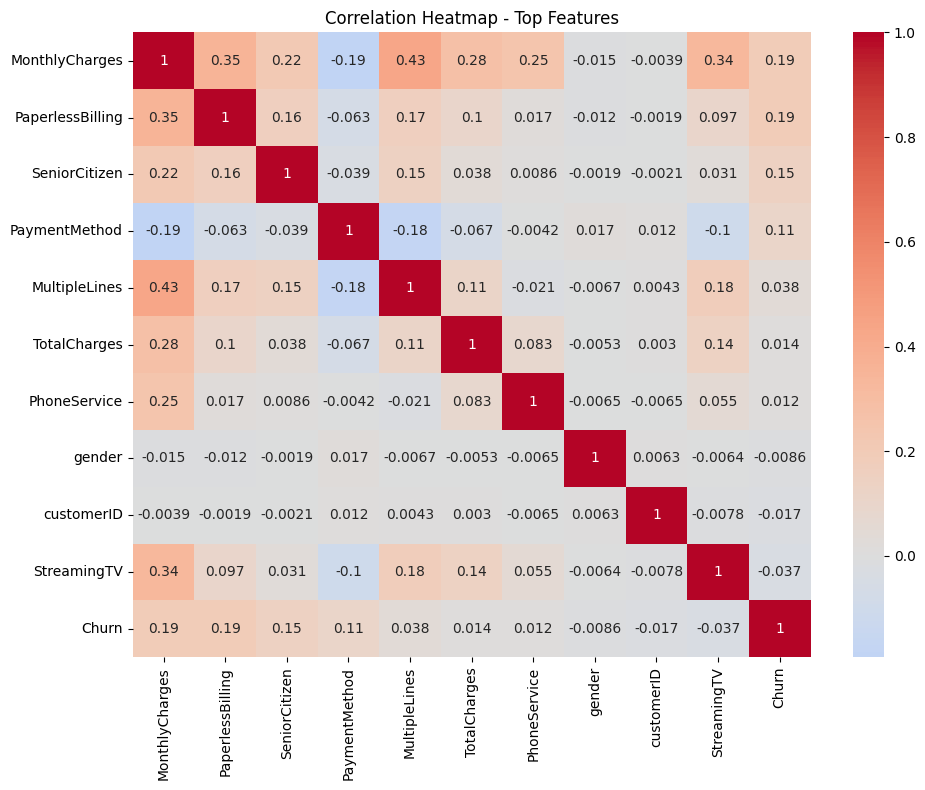

In [24]:
# ===== EDA - KEY INSIGHTS =====

# 1. Churn by Tenure
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df.groupby('Churn')['tenure'].plot(kind='hist', alpha=0.7, bins=30)
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.title('Tenure Distribution by Churn')
plt.legend(['No Churn', 'Churn'])

plt.subplot(1, 2, 2)
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges by Churn')
plt.suptitle('')

plt.tight_layout()
plt.show()

# 2. Churn by Contract Type
print("\n📊 Churn by Contract Type:")
churn_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(churn_contract)

plt.figure(figsize=(10, 6))
churn_contract.plot(kind='bar', stacked=False)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=45)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

# 3. Churn by Services
print("\n📊 Churn by Services:")
services = ['PhoneService', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, service in enumerate(services):
    ax = axes[idx // 3, idx % 3]
    if service in df.columns:
        churn_service = pd.crosstab(df[service], df['Churn'], normalize='index') * 100
        churn_service.plot(kind='bar', ax=ax)
        ax.set_title(f'Churn Rate by {service}')
        ax.set_ylabel('Percentage (%)')
        ax.set_xlabel('')
        ax.legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

# 4. Correlation Analysis
print("\n📊 Key Correlations with Churn:")

# Convert categorical to numerical for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Calculate correlation
correlations = df_encoded.corr()['Churn'].sort_values(ascending=False)
print(correlations)

# Visualize top correlations
plt.figure(figsize=(10, 8))
top_features = correlations[1:11].index
sns.heatmap(df_encoded[list(top_features) + ['Churn']].corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.show()

## Feaature Engineering

In [25]:
def create_features(df):
    """สร้าง features ใหม่ที่มีประโยชน์"""
    
    df_new = df.copy()

    # **************************************************************************
    # *** แก้ไข: บังคับแปลงคอลัมน์ที่ต้องคำนวณให้เป็นตัวเลขและจัดการค่าว่าง (NaN) ***
    # **************************************************************************
    # 1. แปลงเป็นตัวเลข: 'errors="coerce"' จะเปลี่ยนค่าที่ไม่ใช่ตัวเลข (str) ให้เป็น NaN
    df_new['TotalCharges'] = pd.to_numeric(df_new['TotalCharges'], errors='coerce')
    df_new['MonthlyCharges'] = pd.to_numeric(df_new['MonthlyCharges'], errors='coerce')
    df_new['tenure'] = pd.to_numeric(df_new['tenure'], errors='coerce')
    
    # 2. เติมค่าว่าง (Imputation): เติมค่า NaN ที่เกิดจากการแปลงด้วย 0
    #    (เนื่องจากมักเป็นลูกค้าใหม่ที่ยังไม่มีค่าใช้จ่ายรวม)
    df_new['TotalCharges'] = df_new['TotalCharges'].fillna(0)
    df_new['MonthlyCharges'] = df_new['MonthlyCharges'].fillna(0)
    df_new['tenure'] = df_new['tenure'].fillna(0)
    # **************************************************************************


    # 1. Tenure Groups (ตอนนี้ 'tenure' เป็นตัวเลขแล้ว)
    df_new['tenure_group'] = pd.cut(df_new['tenure'], 
                                    bins=[0, 12, 24, 48, 72],
                                    labels=['0-1 year', '1-2 years', 
                                            '2-4 years', '4+ years'],
                                    right=False) # ใช้ right=False เพื่อรวม 0 ใน bin แรก
    
    # 2. Total Charges per Month (ตอนนี้ 'TotalCharges' และ 'tenure' เป็นตัวเลขแล้ว)
    df_new['total_charges_per_month'] = df_new['TotalCharges'] / (df_new['tenure'] + 1)
    
    # ... (โค้ดส่วนที่ 3 ถึง 7 ที่เหลือ)
    
    # 3. Services Count
    service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                    'StreamingTV', 'StreamingMovies']
    
    def count_services(row):
        count = 0
        for col in service_cols:
            if row.get(col) == 'Yes': 
                count += 1
        return count
    
    df_new['services_count'] = df_new.apply(count_services, axis=1)
    
    # 4. Customer Value Score (CLV proxy)
    df_new['customer_value'] = df_new['tenure'] * df_new['MonthlyCharges']
    
    # 5. High Value Customer Flag
    df_new['high_value'] = (df_new['customer_value'] > 
                            df_new['customer_value'].quantile(0.75)).astype(int)
    
    # 6. Payment Risk Score
    payment_risk = {
        'Electronic check': 3,
        'Mailed check': 2,
        'Bank transfer (automatic)': 1,
        'Credit card (automatic)': 1
    }
    df_new['payment_risk'] = df_new['PaymentMethod'].map(payment_risk)
    
    # 7. Contract Security Score
    contract_score = {
        'Month-to-month': 0,
        'One year': 1,
        'Two year': 2
    }
    df_new['contract_security'] = df_new['Contract'].map(contract_score)
    
    return df_new

# Apply feature engineering
df_featured = create_features(df)

print("\n🔧 New Features Created:")
new_features = ['tenure_group', 'total_charges_per_month', 'services_count',
                'customer_value', 'high_value', 'payment_risk', 'contract_security']
print(df_featured[new_features].head())

print("\n📊 Feature Statistics:")
print(df_featured[new_features].describe())


🔧 New Features Created:
  tenure_group  total_charges_per_month  services_count  customer_value  \
0     0-1 year                14.925000               1           29.85   
1    2-4 years                53.985714               3         1936.30   
2     0-1 year                36.050000               3          107.70   
3    2-4 years                40.016304               3         1903.50   
4     0-1 year                50.550000               1          141.40   

   high_value  payment_risk  contract_security  
0           0             3                  0  
1           0             2                  1  
2           0             2                  0  
3           0             1                  1  
4           0             3                  0  

📊 Feature Statistics:
       total_charges_per_month  services_count  customer_value   high_value  \
count              7043.000000     7043.000000     7043.000000  7043.000000   
mean                 58.990789        2.941076   

## Data Processing

In [26]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ===== DATA PREPROCESSING =====

def preprocess_data(df):
    """เตรียมข้อมูลสำหรับ modeling"""
    
    df_processed = df.copy()
    
    # 1. Handle missing values
    # TotalCharges might have missing values
    if 'TotalCharges' in df_processed.columns:
        df_processed['TotalCharges'] = pd.to_numeric(
            df_processed['TotalCharges'], errors='coerce'
        )
        df_processed['TotalCharges'].fillna(0, inplace=True)
    
    # 2. Encode target variable
    df_processed['Churn'] = (df_processed['Churn'] == 'Yes').astype(int)
    
    # 3. Separate features and target
    target = 'Churn'
    id_col = 'customerID' if 'customerID' in df_processed.columns else None
    
    if id_col:
        df_processed = df_processed.drop(columns=[id_col])
    
    X = df_processed.drop(columns=[target])
    y = df_processed[target]
    
    # 4. Identify numerical and categorical columns
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"\n📊 Feature Summary:")
    print(f"Total Features: {len(X.columns)}")
    print(f"Numerical: {len(numerical_cols)}")
    print(f"Categorical: {len(categorical_cols)}")
    
    # 5. Encode categorical variables
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le
    
    # 6. Scale numerical features
    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    
    return X, y, scaler, le_dict, numerical_cols, categorical_cols

# Preprocess data
X, y, scaler, le_dict, num_cols, cat_cols = preprocess_data(df_featured)

print("\n✅ Data Preprocessing Complete!")
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.2f}%")


📊 Feature Summary:
Total Features: 26
Numerical: 10
Categorical: 16



✅ Data Preprocessing Complete!
Features shape: (7043, 26)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.54%


## Handle Imbalanced Data

In [27]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# ===== HANDLE IMBALANCED DATA =====

print("\n⚖️ HANDLING IMBALANCED DATA")
print("=" * 60)

# Original distribution
print("\n📊 Original Distribution:")
print(y.value_counts())
print(f"Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

# Split data first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

# Apply SMOTE
print("\n🔄 Applying SMOTE...")
smote = SMOTE(random_state=42, sampling_strategy=0.8)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n✅ After SMOTE:")
print(f"Training set: {X_train_balanced.shape}")
print(f"Churn distribution:\n{pd.Series(y_train_balanced).value_counts()}")
print(f"New imbalance ratio: {pd.Series(y_train_balanced).value_counts()[0] / pd.Series(y_train_balanced).value_counts()[1]:.2f}:1")


⚖️ HANDLING IMBALANCED DATA

📊 Original Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Imbalance ratio: 2.77:1

📊 Train set: (5634, 26)
Test set: (1409, 26)

Train churn rate: 26.54%
Test churn rate: 26.54%

🔄 Applying SMOTE...

✅ After SMOTE:
Training set: (7450, 26)
Churn distribution:
Churn
0    4139
1    3311
Name: count, dtype: int64
New imbalance ratio: 1.25:1


## Model Training & Comparison


🤖 TRAINING MULTIPLE MODELS

Training: Logistic Regression

📊 Results:
Accuracy:  0.7715
Precision: 0.5558
Recall:    0.6925
F1-Score:  0.6167
ROC-AUC:   0.8386

📋 Confusion Matrix:
[[828 207]
 [115 259]]

True Negatives:  828
False Positives: 207
False Negatives: 115
True Positives:  259

Training: Random Forest

📊 Results:
Accuracy:  0.7722
Precision: 0.5685
Recall:    0.5882
F1-Score:  0.5782
ROC-AUC:   0.8214

📋 Confusion Matrix:
[[868 167]
 [154 220]]

True Negatives:  868
False Positives: 167
False Negatives: 154
True Positives:  220

Training: Gradient Boosting

📊 Results:
Accuracy:  0.7779
Precision: 0.5670
Recall:    0.6898
F1-Score:  0.6224
ROC-AUC:   0.8382

📋 Confusion Matrix:
[[838 197]
 [116 258]]

True Negatives:  838
False Positives: 197
False Negatives: 116
True Positives:  258

Training: XGBoost

📊 Results:
Accuracy:  0.7438
Precision: 0.5123
Recall:    0.7219
F1-Score:  0.5993
ROC-AUC:   0.8143

📋 Confusion Matrix:
[[778 257]
 [104 270]]

True Negatives:  778
False P

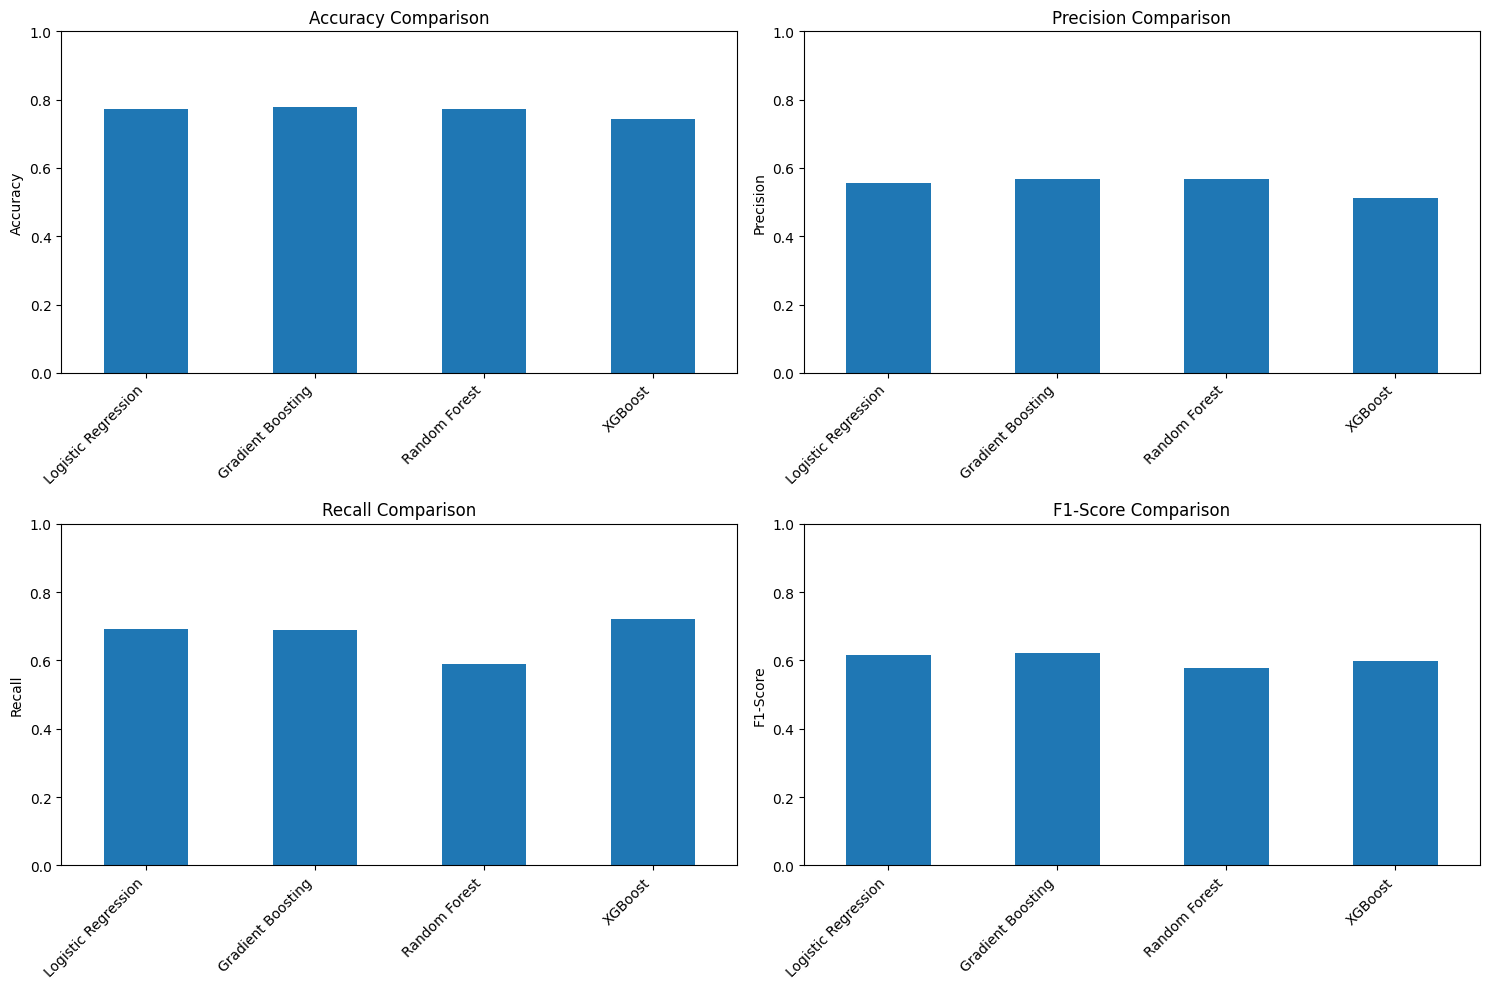


🏆 Best Model: Logistic Regression
ROC-AUC Score: 0.8386


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve, precision_recall_curve)

# ===== MODEL TRAINING =====

print("\n🤖 TRAINING MULTIPLE MODELS")
print("=" * 80)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, 
                                           class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, 
                            scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]))
}

results = []

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n📊 Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    print(f"\n📋 Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"\nTrue Negatives:  {cm[0, 0]}")
    print(f"False Positives: {cm[0, 1]}")
    print(f"False Negatives: {cm[1, 0]}")
    print(f"True Positives:  {cm[1, 1]}")

# Compare all models
print("\n" + "=" * 80)
print("📊 MODEL COMPARISON")
print("=" * 80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print("\n", results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    results_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"ROC-AUC Score: {results_df.iloc[0]['ROC-AUC']:.4f}")

## ROC Curve & Precision-Recall Analysis


📈 ROC CURVE & PRECISION-RECALL ANALYSIS


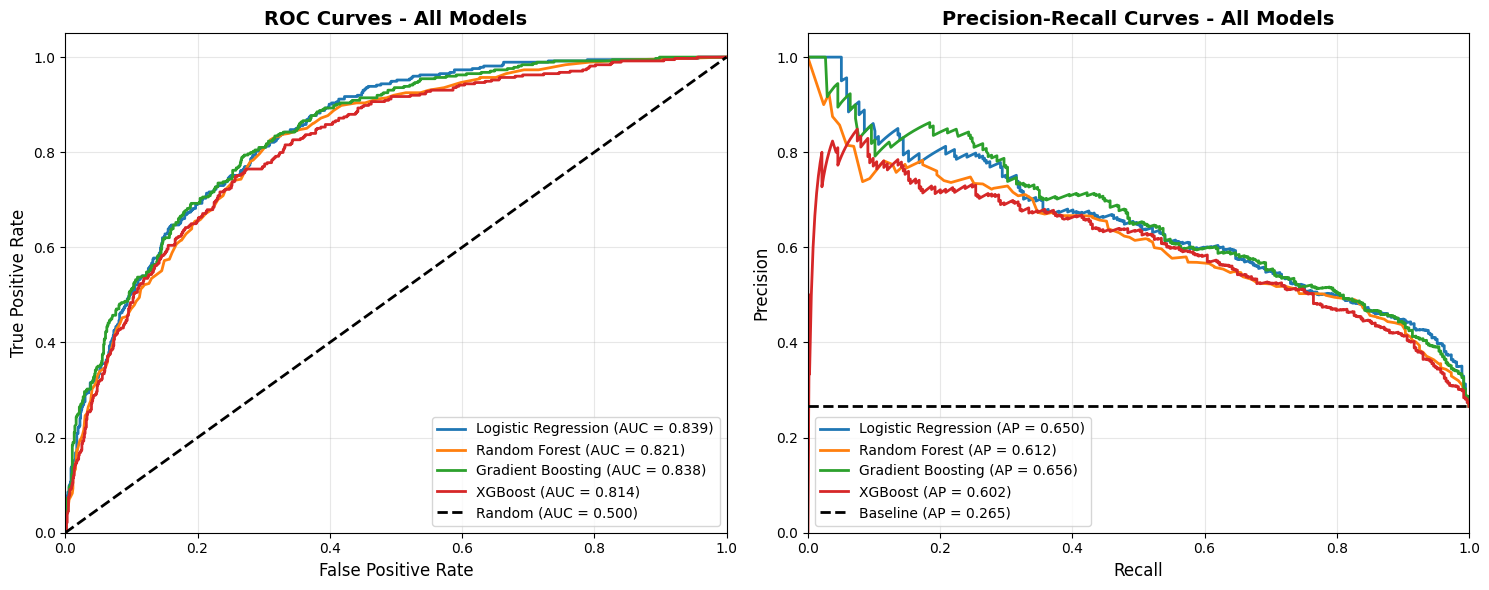


📊 Detailed Analysis for Logistic Regression:

🎯 Performance at Different Thresholds:
------------------------------------------------------------
Threshold    Precision    Recall       F1-Score    
------------------------------------------------------------
0.3          0.4608       0.8636       0.6009      
0.4          0.5009       0.7754       0.6086      
0.5          0.5558       0.6925       0.6167      
0.6          0.5995       0.5882       0.5938      
0.7          0.6579       0.4679       0.5469      

🎯 Optimal Threshold (Maximize F1): 0.4841
   Precision: 0.5471
   Recall: 0.7139
   F1-Score: 0.6195

📊 Confusion Matrix (Optimal Threshold):
[[814 221]
 [107 267]]


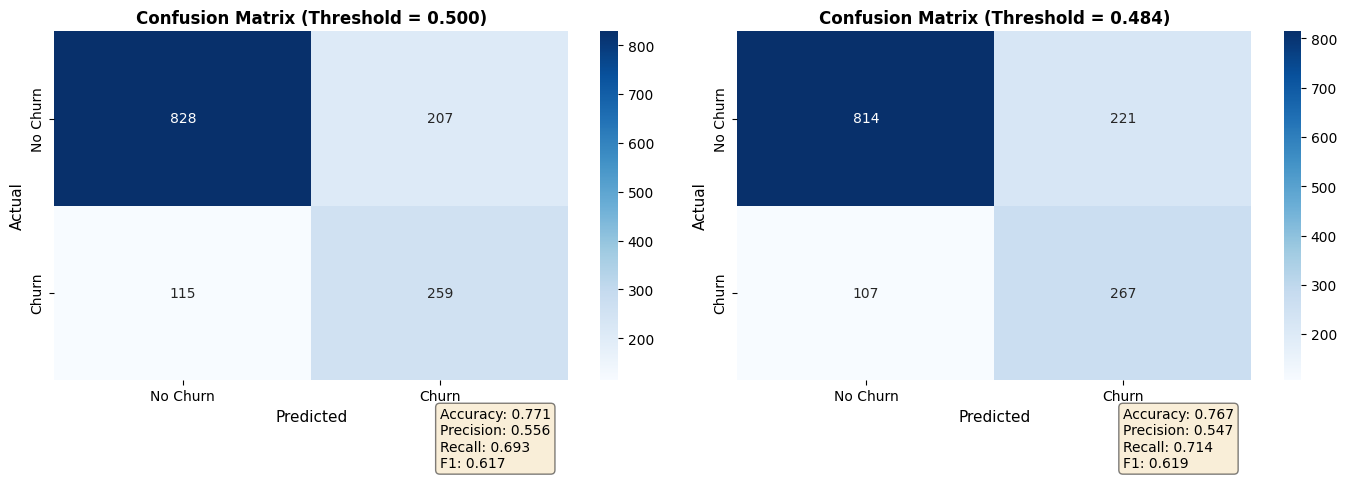

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ===== ROC CURVE & PRECISION-RECALL ANALYSIS =====

print("\n" + "=" * 80)
print("📈 ROC CURVE & PRECISION-RECALL ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. ROC Curves
ax1 = axes[0]

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# 2. Precision-Recall Curves
ax2 = axes[1]

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    ax2.plot(recall, precision, lw=2, label=f'{name} (AP = {avg_precision:.3f})')

# Baseline (random classifier)
baseline = y_test.sum() / len(y_test)
ax2.plot([0, 1], [baseline, baseline], 'k--', lw=2, 
         label=f'Baseline (AP = {baseline:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves - All Models', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed analysis for best model
print(f"\n📊 Detailed Analysis for {best_model_name}:")
print("=" * 60)

y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Different threshold analysis
print("\n🎯 Performance at Different Thresholds:")
print("-" * 60)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_best >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    print(f"{threshold:<12.1f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")

# Optimal threshold (maximize F1)
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_best)
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_pr[optimal_idx]

print(f"\n🎯 Optimal Threshold (Maximize F1): {optimal_threshold:.4f}")
print(f"   Precision: {precision_vals[optimal_idx]:.4f}")
print(f"   Recall: {recall_vals[optimal_idx]:.4f}")
print(f"   F1-Score: {f1_scores[optimal_idx]:.4f}")

# Use optimal threshold
y_pred_optimal = (y_pred_proba_best >= optimal_threshold).astype(int)

print(f"\n📊 Confusion Matrix (Optimal Threshold):")
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print(cm_optimal)

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold (0.5)
y_pred_default = best_model.predict(X_test)
cm_default = confusion_matrix(y_test, y_pred_default)

for idx, (cm, threshold, ax) in enumerate([
    (cm_default, 0.5, axes[0]),
    (cm_optimal, optimal_threshold, axes[1])
]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix (Threshold = {threshold:.3f})', 
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    
    # Add metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    text = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1: {f1:.3f}'
    ax.text(1.5, 2.5, text, fontsize=10, 
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Feature Importance


🔍 FEATURE IMPORTANCE ANALYSIS

📊 Calculating Permutation Importance...
(This may take a few minutes...)

📊 Top 15 Permutation Importance:
----------------------------------------------------------------------
Contract                            0.269269 ± 0.006644
services_count                      0.137544 ± 0.008987
contract_security                   0.093187 ± 0.004887
total_charges_per_month             0.077218 ± 0.009889
InternetService                     0.065224 ± 0.008298
tenure_group                        0.059475 ± 0.003588
OnlineSecurity                      0.054010 ± 0.004538
TechSupport                         0.049539 ± 0.008122
OnlineBackup                        0.045635 ± 0.006163
DeviceProtection                    0.036196 ± 0.004163
TotalCharges                        0.032931 ± 0.005237
StreamingTV                         0.019659 ± 0.005947
StreamingMovies                     0.019233 ± 0.006736
PhoneService                        0.010220 ± 0.004377
Paymen

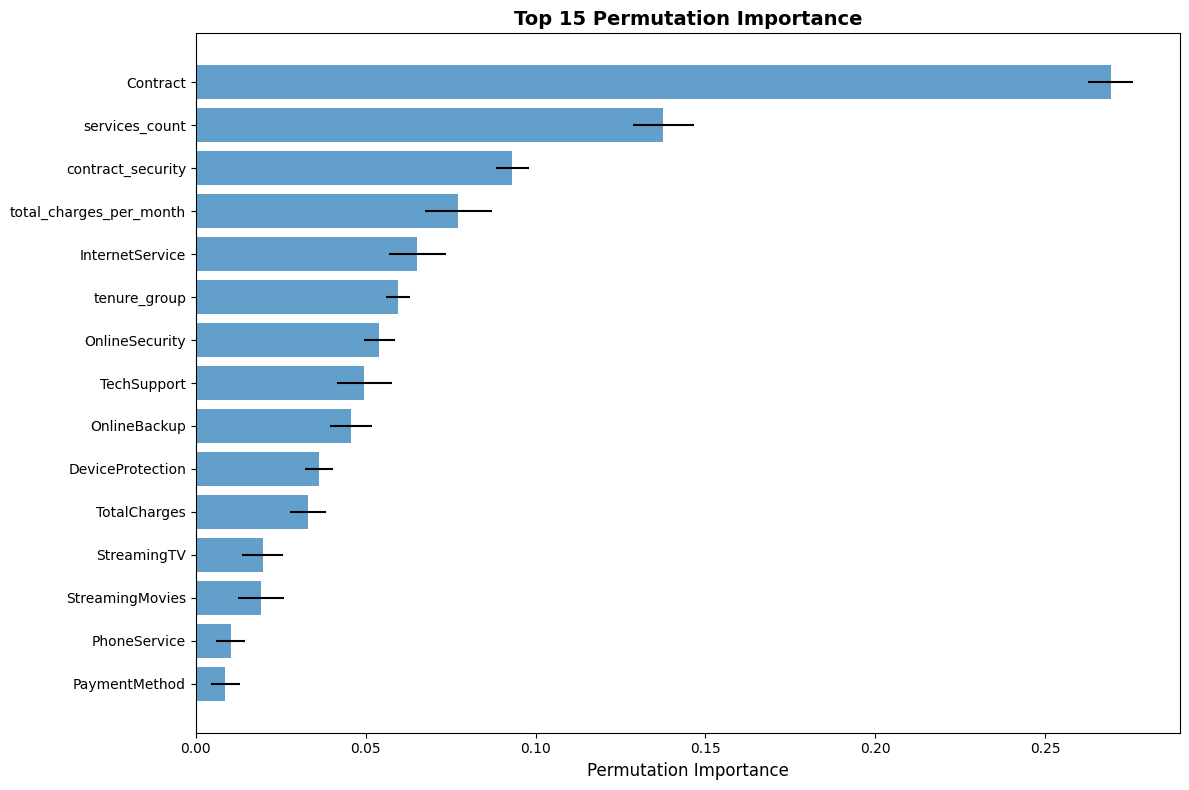

In [30]:
import shap
from sklearn.inspection import permutation_importance

# ===== FEATURE IMPORTANCE ANALYSIS =====

print("\n" + "=" * 80)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# 1. Built-in Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n📊 Top 15 Most Important Features:")
    print("-" * 60)
    for idx, row in feature_importance.head(15).iterrows():
        print(f"{row['Feature']:<35} {row['Importance']:.6f}")
    
    # Visualize
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importance - {best_model_name}', 
             fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 2. Permutation Importance (works for all models)
print("\n📊 Calculating Permutation Importance...")
print("(This may take a few minutes...)")

perm_importance = permutation_importance(
    best_model, X_test, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\n📊 Top 15 Permutation Importance:")
print("-" * 70)
for idx, row in perm_importance_df.head(15).iterrows():
    print(f"{row['Feature']:<35} {row['Importance']:.6f} ± {row['Std']:.6f}")

# Visualize
plt.figure(figsize=(12, 8))
top_perm = perm_importance_df.head(15)
plt.barh(range(len(top_perm)), top_perm['Importance'], 
        xerr=top_perm['Std'], alpha=0.7)
plt.yticks(range(len(top_perm)), top_perm['Feature'])
plt.xlabel('Permutation Importance', fontsize=12)
plt.title('Top 15 Permutation Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Cost Benefit Analysis


💰 COST-BENEFIT ANALYSIS & ROI CALCULATION

📋 Business Cost Parameters:
------------------------------------------------------------
Customer Lifetime Value:     $2,000
Retention Program Cost:      $200
New Customer Acquisition:    $500
False Positive Cost:         $200
False Negative Cost:         $2,000

📊 SCENARIO 1: Do Nothing (No Predictive Model)

Customers who churned: 374
Cost of lost customers: $748,000
Net Benefit: $-748,000

📊 SCENARIO 2: Intervene with All Customers

Intervention cost: $281,800
Customers saved: 374
Savings: $748,000
Net Benefit: $466,200
ROI: 165.4%

📊 SCENARIO 3: Use ML Model (Threshold = 0.5)

Confusion Matrix:
  True Negatives:   828
  False Positives:  207
  False Negatives:  115
  True Positives:   259

Costs:
  False Positives: $41,400
  False Negatives: $230,000
  True Positives:  $51,800
  Total Cost:      $323,200

Savings:           $518,000
Net Benefit:       $194,800
ROI:               60.3%

📊 SCENARIO 4: Use ML Model (Threshold = 0.484)

Confu

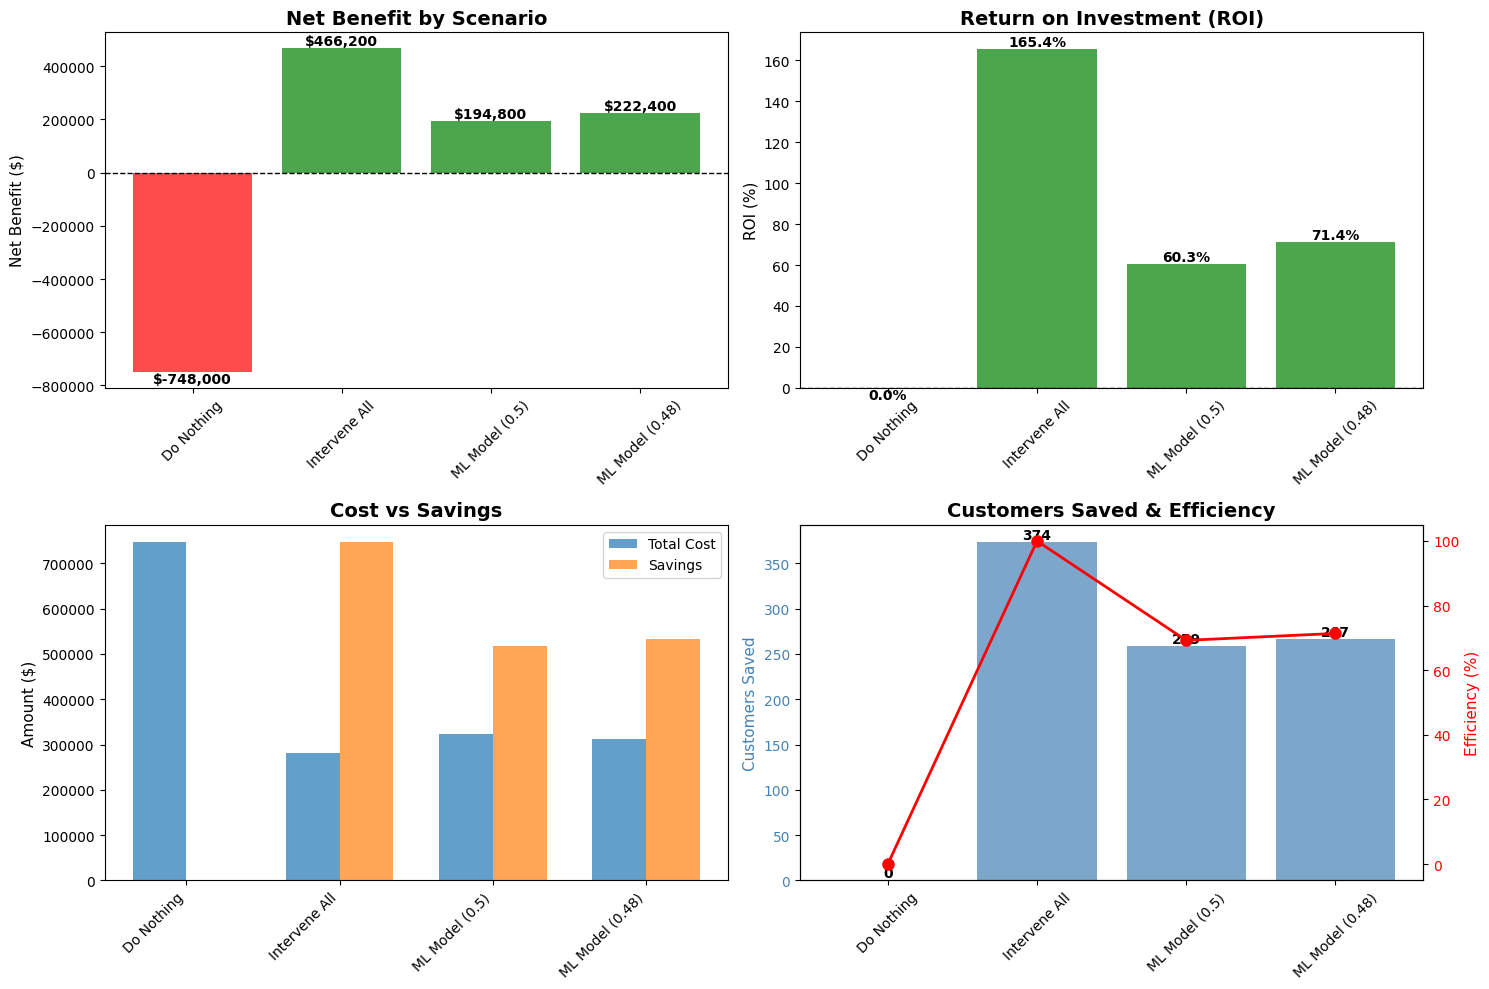


🎯 COST-SENSITIVE THRESHOLD OPTIMIZATION

🏆 Optimal Business Threshold: 0.100
   Max Net Benefit: $506,200
   ROI: 232.4%
   True Positives: 362
   False Positives: 607
   False Negatives: 12


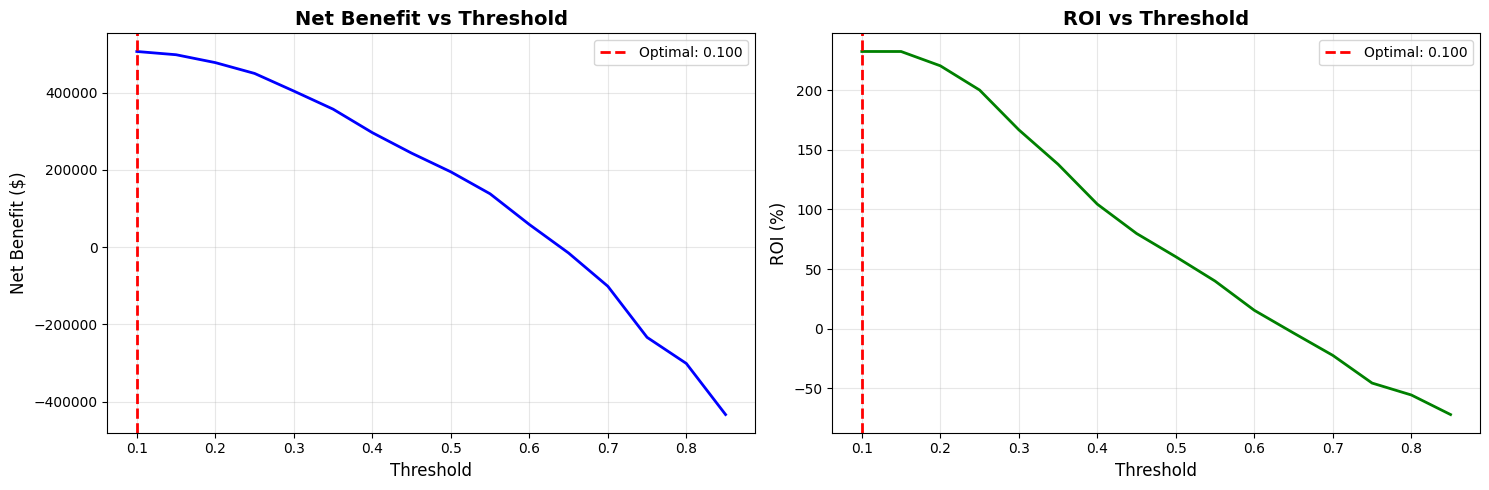


💡 Key Business Insights:
1. Using the ML model with optimal threshold (0.100)
   can save $222,400 compared to doing nothing

2. The model achieves 71.4% ROI on retention investments

3. We can successfully retain 267 customers
   out of 374 at-risk customers (71.4%)

4. The cost of model errors:
4. The cost of model errors:
   - False Positives: $44,200 (customers incorrectly targeted)
   - False Negatives: $214,000 (missed at-risk customers)

5. If the company invests $200 per customer in retention,
   the model achieves a positive ROI of 71.4% compared to doing nothing.

6. Threshold optimization shows that adjusting the cutoff from 0.5 to 0.100 increases net profit by $27,600.

7. In summary, data-driven targeting using ML yields the best trade-off between
   intervention costs and customer lifetime value preservation.

🏁 FINAL TAKEAWAY
✅ Using the ML model with an optimized threshold (0.100) provides the highest ROI (71.4%), saving approximately $222,400 compared to no interventi

In [31]:
# ===== COST-BENEFIT ANALYSIS =====

print("\n" + "=" * 80)
print("💰 COST-BENEFIT ANALYSIS & ROI CALCULATION")
print("=" * 80)

# Define business costs
print("\n📋 Business Cost Parameters:")
print("-" * 60)

CUSTOMER_LIFETIME_VALUE = 2000  # Average CLV in dollars
RETENTION_PROGRAM_COST = 200    # Cost per customer intervention
ACQUISITION_COST = 500          # Cost to acquire new customer
FALSE_POSITIVE_COST = RETENTION_PROGRAM_COST  # Wasted intervention
FALSE_NEGATIVE_COST = CUSTOMER_LIFETIME_VALUE  # Lost customer

print(f"Customer Lifetime Value:     ${CUSTOMER_LIFETIME_VALUE:,}")
print(f"Retention Program Cost:      ${RETENTION_PROGRAM_COST:,}")
print(f"New Customer Acquisition:    ${ACQUISITION_COST:,}")
print(f"False Positive Cost:         ${FALSE_POSITIVE_COST:,}")
print(f"False Negative Cost:         ${FALSE_NEGATIVE_COST:,}")

# Calculate costs for different scenarios

def calculate_business_impact(y_true, y_pred, y_pred_proba=None, threshold=0.5):
    """Calculate business impact of predictions"""
    
    if y_pred_proba is not None:
        y_pred = (y_pred_proba >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Costs
    cost_fp = fp * FALSE_POSITIVE_COST  # Unnecessary interventions
    cost_fn = fn * FALSE_NEGATIVE_COST  # Lost customers
    cost_tp = tp * RETENTION_PROGRAM_COST  # Successful interventions
    
    total_cost = cost_fp + cost_fn + cost_tp
    
    # Savings
    saved_customers = tp  # Customers we saved
    savings = saved_customers * CUSTOMER_LIFETIME_VALUE
    
    # Net benefit
    net_benefit = savings - total_cost
    
    # ROI
    roi = (net_benefit / total_cost * 100) if total_cost > 0 else 0
    
    return {
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Cost (FP)': cost_fp,
        'Cost (FN)': cost_fn,
        'Cost (TP)': cost_tp,
        'Total Cost': total_cost,
        'Savings': savings,
        'Net Benefit': net_benefit,
        'ROI (%)': roi
    }

# Scenario 1: Do Nothing (No Model)
print("\n" + "=" * 60)
print("📊 SCENARIO 1: Do Nothing (No Predictive Model)")
print("=" * 60)

actual_churners = y_test.sum()
actual_non_churners = len(y_test) - actual_churners

cost_no_model = actual_churners * CUSTOMER_LIFETIME_VALUE
print(f"\nCustomers who churned: {actual_churners}")
print(f"Cost of lost customers: ${cost_no_model:,}")
print(f"Net Benefit: ${-cost_no_model:,}")

# Scenario 2: Intervene with Everyone
print("\n" + "=" * 60)
print("📊 SCENARIO 2: Intervene with All Customers")
print("=" * 60)

cost_all_intervention = len(y_test) * RETENTION_PROGRAM_COST
saved_all = actual_churners  # Assume we save all churners
savings_all = saved_all * CUSTOMER_LIFETIME_VALUE
net_benefit_all = savings_all - cost_all_intervention

print(f"\nIntervention cost: ${cost_all_intervention:,}")
print(f"Customers saved: {saved_all}")
print(f"Savings: ${savings_all:,}")
print(f"Net Benefit: ${net_benefit_all:,}")
print(f"ROI: {(net_benefit_all/cost_all_intervention*100):.1f}%")

# Scenario 3: Use ML Model (Default Threshold)
print("\n" + "=" * 60)
print("📊 SCENARIO 3: Use ML Model (Threshold = 0.5)")
print("=" * 60)

y_pred_default = best_model.predict(X_test)
impact_default = calculate_business_impact(y_test, y_pred_default)

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {impact_default['True Negatives']:4d}")
print(f"  False Positives: {impact_default['False Positives']:4d}")
print(f"  False Negatives: {impact_default['False Negatives']:4d}")
print(f"  True Positives:  {impact_default['True Positives']:4d}")

print(f"\nCosts:")
print(f"  False Positives: ${impact_default['Cost (FP)']:,}")
print(f"  False Negatives: ${impact_default['Cost (FN)']:,}")
print(f"  True Positives:  ${impact_default['Cost (TP)']:,}")
print(f"  Total Cost:      ${impact_default['Total Cost']:,}")

print(f"\nSavings:           ${impact_default['Savings']:,}")
print(f"Net Benefit:       ${impact_default['Net Benefit']:,}")
print(f"ROI:               {impact_default['ROI (%)']:.1f}%")

# Scenario 4: Use ML Model (Optimal Threshold)
print("\n" + "=" * 60)
print(f"📊 SCENARIO 4: Use ML Model (Threshold = {optimal_threshold:.3f})")
print("=" * 60)

impact_optimal = calculate_business_impact(y_test, None, y_pred_proba_best, optimal_threshold)

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {impact_optimal['True Negatives']:4d}")
print(f"  False Positives: {impact_optimal['False Positives']:4d}")
print(f"  False Negatives: {impact_optimal['False Negatives']:4d}")
print(f"  True Positives:  {impact_optimal['True Positives']:4d}")

print(f"\nCosts:")
print(f"  False Positives: ${impact_optimal['Cost (FP)']:,}")
print(f"  False Negatives: ${impact_optimal['Cost (FN)']:,}")
print(f"  True Positives:  ${impact_optimal['Cost (TP)']:,}")
print(f"  Total Cost:      ${impact_optimal['Total Cost']:,}")

print(f"\nSavings:           ${impact_optimal['Savings']:,}")
print(f"Net Benefit:       ${impact_optimal['Net Benefit']:,}")
print(f"ROI:               {impact_optimal['ROI (%)']:.1f}%")

# Compare all scenarios
print("\n" + "=" * 80)
print("📊 SCENARIO COMPARISON")
print("=" * 80)

comparison = pd.DataFrame({
    'Scenario': ['Do Nothing', 'Intervene All', 'ML Model (0.5)', f'ML Model ({optimal_threshold:.2f})'],
    'Total Cost': [
        cost_no_model,
        cost_all_intervention,
        impact_default['Total Cost'],
        impact_optimal['Total Cost']
    ],
    'Savings': [
        0,
        savings_all,
        impact_default['Savings'],
        impact_optimal['Savings']
    ],
    'Net Benefit': [
        -cost_no_model,
        net_benefit_all,
        impact_default['Net Benefit'],
        impact_optimal['Net Benefit']
    ],
    'ROI (%)': [
        0,
        (net_benefit_all/cost_all_intervention*100),
        impact_default['ROI (%)'],
        impact_optimal['ROI (%)']
    ]
})

print("\n", comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Net Benefit
ax1 = axes[0, 0]
colors = ['red' if x < 0 else 'green' for x in comparison['Net Benefit']]
ax1.bar(comparison['Scenario'], comparison['Net Benefit'], color=colors, alpha=0.7)
ax1.set_title('Net Benefit by Scenario', fontsize=14, fontweight='bold')
ax1.set_ylabel('Net Benefit ($)', fontsize=11)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison['Net Benefit']):
    ax1.text(i, v, f'${v:,.0f}', ha='center', 
            va='bottom' if v > 0 else 'top', fontweight='bold')

# 2. ROI
ax2 = axes[0, 1]
colors = ['red' if x < 0 else 'green' for x in comparison['ROI (%)']]
ax2.bar(comparison['Scenario'], comparison['ROI (%)'], color=colors, alpha=0.7)
ax2.set_title('Return on Investment (ROI)', fontsize=14, fontweight='bold')
ax2.set_ylabel('ROI (%)', fontsize=11)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison['ROI (%)']):
    ax2.text(i, v, f'{v:.1f}%', ha='center', 
            va='bottom' if v > 0 else 'top', fontweight='bold')

# 3. Cost vs Savings
ax3 = axes[1, 0]
x = np.arange(len(comparison))
width = 0.35
ax3.bar(x - width/2, comparison['Total Cost'], width, label='Total Cost', alpha=0.7)
ax3.bar(x + width/2, comparison['Savings'], width, label='Savings', alpha=0.7)
ax3.set_title('Cost vs Savings', fontsize=14, fontweight='bold')
ax3.set_ylabel('Amount ($)', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(comparison['Scenario'], rotation=45, ha='right')
ax3.legend()

# 4. Customers Saved
ax4 = axes[1, 1]
customers_saved = [0, saved_all, impact_default['True Positives'], impact_optimal['True Positives']]
efficiency = [0, 100, 
             (impact_default['True Positives']/actual_churners*100),
             (impact_optimal['True Positives']/actual_churners*100)]

ax4_twin = ax4.twinx()
bar = ax4.bar(comparison['Scenario'], customers_saved, alpha=0.7, color='steelblue')
line = ax4_twin.plot(comparison['Scenario'], efficiency, 'ro-', linewidth=2, markersize=8)

ax4.set_title('Customers Saved & Efficiency', fontsize=14, fontweight='bold')
ax4.set_ylabel('Customers Saved', fontsize=11, color='steelblue')
ax4_twin.set_ylabel('Efficiency (%)', fontsize=11, color='red')
ax4.tick_params(axis='x', rotation=45)
ax4.tick_params(axis='y', labelcolor='steelblue')
ax4_twin.tick_params(axis='y', labelcolor='red')

for i, v in enumerate(customers_saved):
    ax4.text(i, v, f'{v}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Cost-sensitive threshold optimization
print("\n" + "=" * 80)
print("🎯 COST-SENSITIVE THRESHOLD OPTIMIZATION")
print("=" * 80)

thresholds_test = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for threshold in thresholds_test:
    impact = calculate_business_impact(y_test, None, y_pred_proba_best, threshold)
    threshold_results.append({
        'Threshold': threshold,
        'Net Benefit': impact['Net Benefit'],
        'ROI': impact['ROI (%)'],
        'TP': impact['True Positives'],
        'FP': impact['False Positives'],
        'FN': impact['False Negatives']
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold_idx = threshold_df['Net Benefit'].idxmax()
best_threshold_value = threshold_df.loc[best_threshold_idx, 'Threshold']

print(f"\n🏆 Optimal Business Threshold: {best_threshold_value:.3f}")
print(f"   Max Net Benefit: ${threshold_df.loc[best_threshold_idx, 'Net Benefit']:,.0f}")
print(f"   ROI: {threshold_df.loc[best_threshold_idx, 'ROI']:.1f}%")
print(f"   True Positives: {threshold_df.loc[best_threshold_idx, 'TP']:.0f}")
print(f"   False Positives: {threshold_df.loc[best_threshold_idx, 'FP']:.0f}")
print(f"   False Negatives: {threshold_df.loc[best_threshold_idx, 'FN']:.0f}")

# Plot threshold impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
ax1.plot(threshold_df['Threshold'], threshold_df['Net Benefit'], 'b-', linewidth=2)
ax1.axvline(x=best_threshold_value, color='r', linestyle='--', linewidth=2,
           label=f'Optimal: {best_threshold_value:.3f}')
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Net Benefit ($)', fontsize=12)
ax1.set_title('Net Benefit vs Threshold', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

ax2 = axes[1]
ax2.plot(threshold_df['Threshold'], threshold_df['ROI'], 'g-', linewidth=2)
ax2.axvline(x=best_threshold_value, color='r', linestyle='--', linewidth=2,
           label=f'Optimal: {best_threshold_value:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('ROI (%)', fontsize=12)
ax2.set_title('ROI vs Threshold', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n💡 Key Business Insights:")
print("=" * 60)
print(f"1. Using the ML model with optimal threshold ({best_threshold_value:.3f})")
print(f"   can save ${impact_optimal['Net Benefit']:,.0f} compared to doing nothing")
print(f"\n2. The model achieves {impact_optimal['ROI (%)']:.1f}% ROI on retention investments")
print(f"\n3. We can successfully retain {impact_optimal['True Positives']} customers")
print(f"   out of {actual_churners} at-risk customers ({impact_optimal['True Positives']/actual_churners*100:.1f}%)")
print(f"\n4. The cost of model errors:")
print(f"4. The cost of model errors:")
print(f"   - False Positives: ${impact_optimal['Cost (FP)']:,} (customers incorrectly targeted)")
print(f"   - False Negatives: ${impact_optimal['Cost (FN)']:,} (missed at-risk customers)")

print(f"\n5. If the company invests ${RETENTION_PROGRAM_COST:,} per customer in retention,")
print(f"   the model achieves a positive ROI of {impact_optimal['ROI (%)']:.1f}% "
      f"compared to doing nothing.")

print(f"\n6. Threshold optimization shows that adjusting the cutoff from 0.5 to "
      f"{best_threshold_value:.3f} increases net profit by "
      f"${impact_optimal['Net Benefit'] - impact_default['Net Benefit']:,.0f}.")

print(f"\n7. In summary, data-driven targeting using ML yields the best trade-off between")
print(f"   intervention costs and customer lifetime value preservation.")

print("\n" + "=" * 80)
print("🏁 FINAL TAKEAWAY")
print("=" * 80)
print(f"✅ Using the ML model with an optimized threshold ({best_threshold_value:.3f}) "
      f"provides the highest ROI ({impact_optimal['ROI (%)']:.1f}%), "
      f"saving approximately ${impact_optimal['Net Benefit']:,.0f} "
      f"compared to no intervention.")
print(f"📈 The business can now confidently apply the model in its retention strategy "
      f"to maximize revenue and minimize churn impact.")


In [33]:
import joblib
# ===== MODEL DEPLOYMENT PREPARATION =====
print("\n" + "=" * 80)
print("🚀 MODEL DEPLOYMENT PREPARATION")
print("=" * 80)
# Save the best model
joblib.dump(best_model, 'best_churn_model.pkl')
print("\n✅ Best model saved as 'best_churn_model.pkl'")
joblib.dump(scaler, "scaler.pkl")
print("✅ Scaler saved as 'scaler.pkl'")


🚀 MODEL DEPLOYMENT PREPARATION

✅ Best model saved as 'best_churn_model.pkl'
✅ Scaler saved as 'scaler.pkl'


In [34]:
print(list(enumerate(X.columns)))

[(0, 'gender'), (1, 'SeniorCitizen'), (2, 'Partner'), (3, 'Dependents'), (4, 'tenure'), (5, 'PhoneService'), (6, 'MultipleLines'), (7, 'InternetService'), (8, 'OnlineSecurity'), (9, 'OnlineBackup'), (10, 'DeviceProtection'), (11, 'TechSupport'), (12, 'StreamingTV'), (13, 'StreamingMovies'), (14, 'Contract'), (15, 'PaperlessBilling'), (16, 'PaymentMethod'), (17, 'MonthlyCharges'), (18, 'TotalCharges'), (19, 'tenure_group'), (20, 'total_charges_per_month'), (21, 'services_count'), (22, 'customer_value'), (23, 'high_value'), (24, 'payment_risk'), (25, 'contract_security')]
